In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    r2_score, mean_absolute_error, mean_squared_error
)

In [26]:
# VERİ SETİNİN YÜKLENMESİ
dosya_yolu = r"C:\Users\omer\Desktop\arac_fiyat_tahmin_veri_seti_v1.csv"
veri = pd.read_csv(dosya_yolu)

# AYKIRI DEĞERLERİN TEMİZLENMESİ 
alt_limit = veri['fiyat'].quantile(0.04)
ust_limit = veri['fiyat'].quantile(0.999)

print(f"Eski Veri Boyutu: {len(veri)}")
veri = veri[(veri['fiyat'] >= alt_limit) & (veri['fiyat'] <= ust_limit)]
print(f"Yeni Veri Boyutu: {len(veri)}")
print(f"Fiyat Aralığı: {alt_limit:,.0f} TL - {ust_limit:,.0f} TL\n")

Eski Veri Boyutu: 50380
Yeni Veri Boyutu: 48386
Fiyat Aralığı: 170,000 TL - 7,043,470 TL



In [27]:
# ÖN İŞLEME
if 'marka' in veri.columns:
    veri = veri.drop(columns=['marka', 'seri', 'model'])

# Hedef Değişkenler
veri['fiyat_kategorisi'] = pd.qcut(veri['fiyat'], q=4, labels=['Düşük', 'Orta', 'Yüksek', 'Lüks'])
X = veri.drop(columns=['fiyat', 'fiyat_kategorisi'])
y_reg = veri['fiyat']
y_cls = veri['fiyat_kategorisi']

# Veri Bölme
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_cls, y_test_cls = train_test_split(X, y_cls, test_size=0.2, random_state=42)

In [28]:
# REGRESYON ANALİZİ (Random Forest)
print(" REGRESYON PERFORMANSI ")
rf_reg = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)

# Çapraz Doğrulama
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_results = cross_validate(rf_reg, X, y_reg, cv=kf, scoring=['r2', 'neg_mean_absolute_error'])

rf_reg.fit(X_train, y_train_reg)
y_pred_reg = rf_reg.predict(X_test)

print(f"CV R2 Ortalaması: %{cv_results['test_r2'].mean()*100:.2f}")
print(f"Test R2 Skoru: %{r2_score(y_test_reg, y_pred_reg)*100:.2f}")
print(f"Test MAE: {mean_absolute_error(y_test_reg, y_pred_reg):,.2f} TL")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)):,.2f} TL\n")

 REGRESYON PERFORMANSI 
CV R2 Ortalaması: %96.09
Test R2 Skoru: %96.08
Test MAE: 64,545.28 TL
Test RMSE: 119,295.27 TL



In [29]:
# SINIFLANDIRMA ANALİZİ 
print(" SINIFLANDIRMA PERFORMANSI ")
rf_cls = RandomForestClassifier(n_estimators=100, random_state=42)
rf_cls.fit(X_train, y_train_cls)
y_pred_cls = rf_cls.predict(X_test)

print(f"Accuracy: %{accuracy_score(y_test_cls, y_pred_cls)*100:.2f}")
print("\nSınıflandırma Raporu:")
print(classification_report(y_test_cls, y_pred_cls))

 SINIFLANDIRMA PERFORMANSI 
Accuracy: %85.80

Sınıflandırma Raporu:
              precision    recall  f1-score   support

       Düşük       0.89      0.87      0.88      2434
        Lüks       0.93      0.93      0.93      2377
        Orta       0.77      0.81      0.79      2412
      Yüksek       0.84      0.83      0.84      2455

    accuracy                           0.86      9678
   macro avg       0.86      0.86      0.86      9678
weighted avg       0.86      0.86      0.86      9678



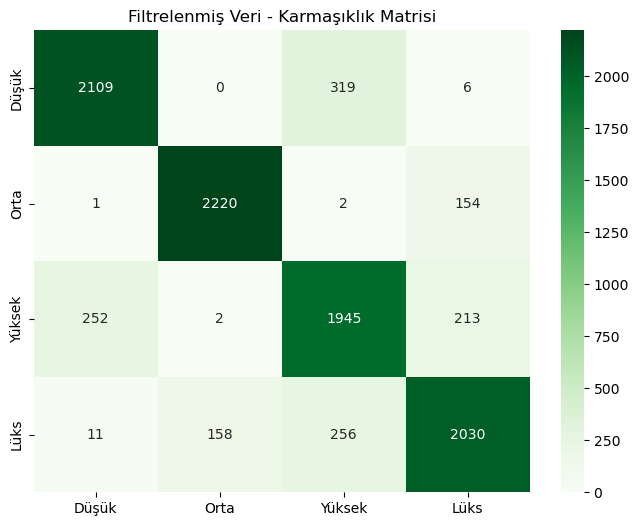

In [30]:
# GÖRSELLEŞTİRME 

# Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test_cls, y_pred_cls)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Düşük', 'Orta', 'Yüksek', 'Lüks'],
            yticklabels=['Düşük', 'Orta', 'Yüksek', 'Lüks'])
plt.title('Filtrelenmiş Veri - Karmaşıklık Matrisi')
plt.show()



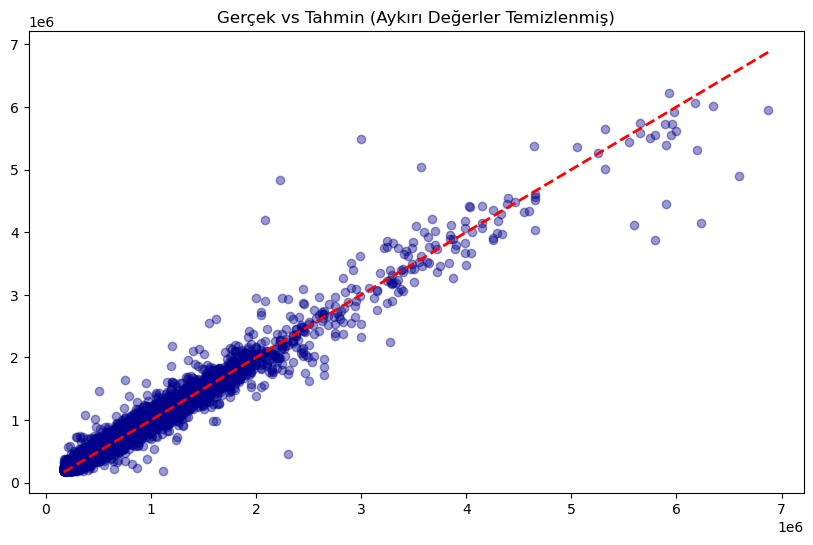

In [31]:
# Gerçek vs Tahmin Grafiği

plt.figure(figsize=(10,6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.4, color='darkblue')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.title('Gerçek vs Tahmin (Aykırı Değerler Temizlenmiş)')
plt.show()

In [32]:
# ÖZELLİK ÖNEM SIRALAMASININ HESAPLANMASI
# Regresyon modelimizden (rf_reg) özelliklerin ağırlıklarını alıyoruz
importances = rf_reg.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Özellik': feature_names,
    'Önem Skoru': importances
}).sort_values(by='Önem Skoru', ascending=False)

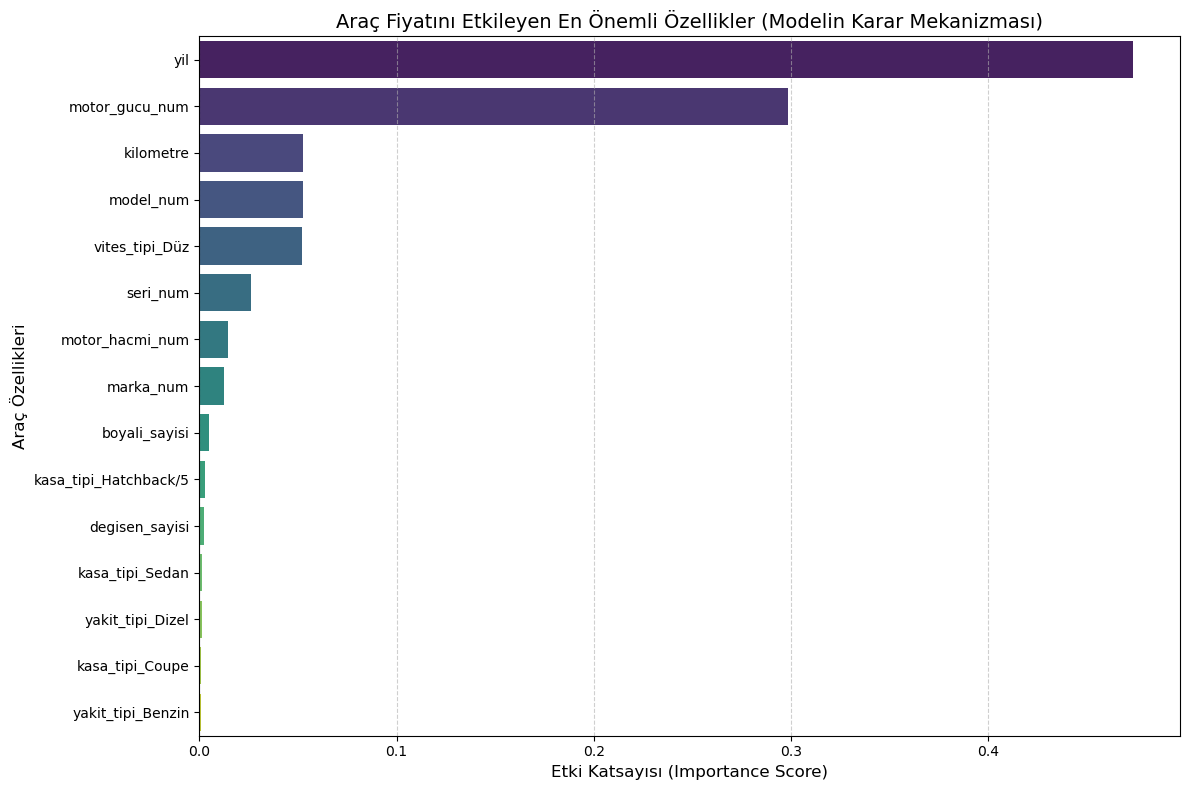

In [37]:
plt.figure(figsize=(12, 8))
sns.barplot(
    x="Önem Skoru", 
    y="Özellik", 
    data=feature_importance_df.head(15), # En önemli 15 özelliği göster
    palette="viridis",
    hue="Özellik",
    legend=False
)

plt.title('Araç Fiyatını Etkileyen En Önemli Özellikler (Modelin Karar Mekanizması)', fontsize=14)
plt.xlabel('Etki Katsayısı (Importance Score)', fontsize=12)
plt.ylabel('Araç Özellikleri', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [34]:
# Kaydedilecek nesneleri bir sözlük yapısında topluyoruz
model_paketi = {
    'regresyon_modeli': rf_reg,
    'siniflandirma_modeli': rf_cls,
    'egitim_sutunlari': X.columns.tolist(),
    'alt_limit': alt_limit,
    'ust_limit': ust_limit
}

joblib.dump(model_paketi, "random_forest.joblib")

print("✅ Model başarıyla kaydedildi.")

✅ Model başarıyla kaydedildi.


In [36]:
# Fiyat Tahmin Fonksiyonu 
def arac_fiyat_tahmin(model, arac_bilgisi, egitim_sutunlari):
    df_input = pd.DataFrame([arac_bilgisi])
    # Eğitimdeki tüm sütunların varlığını kontrol et ve eksikleri 0 ile doldur
    for col in egitim_sutunlari:
        if col not in df_input.columns:
            df_input[col] = 0
    # Sütun sırasını eşitle
    df_input = df_input[egitim_sutunlari]
    return model.predict(df_input)[0]

# Örnek Uygulama 
yeni_arac = {
    "yil": 2021,
    "kilometre": 63000,
    "degisen_sayisi": 0,
    "boyali_sayisi": 0,
    "motor_hacmi_num": 1490,
    "motor_gucu_num": 125,
    "marka_num": 50,      # Toyota ID
    "seri_num": 144,      # Corolla ID
    "model_num": 940,     # 1.5 Dream ID
    "vites_tipi_Düz": 0,
    "vites_tipi_Otomatik": 1,
    "vites_tipi_Yarı Otomatik": 0,
    "yakit_tipi_Benzin": 1,
    "yakit_tipi_Dizel": 0,
    "yakit_tipi_Elektrik": 0,
    "yakit_tipi_Hibrit": 0,
    "yakit_tipi_LPG & Benzin": 0,
    "kasa_tipi_Cabrio": 0,
    "kasa_tipi_Coupe": 0,
    "kasa_tipi_Hatchback/3": 0,
    "kasa_tipi_Hatchback/5": 0,
    "kasa_tipi_MPV": 0,
    "kasa_tipi_Pick-up": 0,
    "kasa_tipi_Roadster": 0,
    "kasa_tipi_SUV": 0,
    "kasa_tipi_Sedan": 1,
    "kasa_tipi_Station wagon": 0
}

tahmin_fiyat = arac_fiyat_tahmin(rf_reg, yeni_arac, X.columns)
print(f"\nGirilen Aracın Tahmini Fiyatı: {tahmin_fiyat:,.0f} TL")



Girilen Aracın Tahmini Fiyatı: 1,434,324 TL
